In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

pandas/numpy — таблица и числа, matplotlib — графики, adfuller/kpss — стационарность, acorr_ljungbox — «белый шум или нет», plot_acf — столбики автокорреляции. Без этой ячейки остальное не запустится.

In [2]:
url = (
    "https://raw.githubusercontent.com/tirthajyoti/Deep-learning-with-Python/"
    "80f337d1584fb123f1a8f7dce0ad190f1a08ce14/"
    "Data/historical-hourly-weather-data/humidity.csv"
)

Тот же файл, что в лекции: почасовая влажность городов, 2012-10-01 — 2017-11-30. Пока только строка url, данные ещё не загружены.

In [3]:
humidity = pd.read_csv(url)
print(humidity.shape)
humidity.head()

(45253, 37)


,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN
1,2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2,2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
3,2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
4,2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0


read_csv без разбора дат. Печатает (45253, 37) и head(). 

Видно: колонка datetime ещё обычное поле, индекс 0, 1, 2…, первая строка почти вся NaN, Portland со второй строки = 81%.

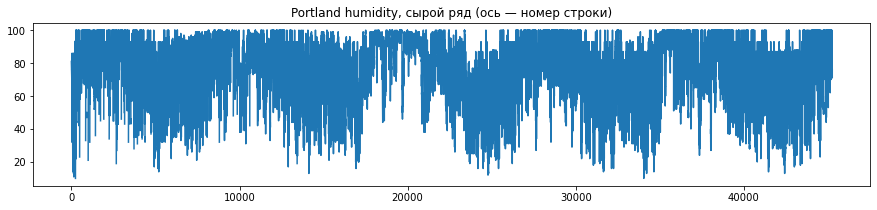

In [4]:
humidity['Portland'].plot(figsize=(15, 3))
plt.title('Portland humidity, сырой ряд (ось — номер строки)')
plt.show()

Ось x — номер строки, не календарь. Нужен, чтобы потом сравнить с графиком, где ось уже годы. Заголовок это прямо говорит.

In [5]:
humidity.dtypes[:3]

datetime      object
Vancouver    float64
Portland     float64
dtype: object

datetime = object (строка), города = float64. Подтверждение: пока pandas не считает это временем, loc['2016'] и resample не заработают.

In [6]:
humidity = pd.read_csv(url, index_col='datetime', parse_dates=['datetime'])
humidity.head()

,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,Denver,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
datetime,,,,,,,,,,,,,,,,,,,,,
2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN
2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,62.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,62.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,62.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,62.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0


Тот же CSV, но parse_dates=['datetime'] и index_col='datetime'. Индекс становится DatetimeIndex, колонок 36 (дата ушла в индекс). С этой ячейки таблица — настоящий набор рядов.

In [7]:
humidity.loc['2016', 'Portland']

datetime
2016-01-01 00:00:00    47.0
2016-01-01 01:00:00    47.0
2016-01-01 02:00:00    59.0
2016-01-01 03:00:00    55.0
2016-01-01 04:00:00    55.0
                       ... 
2016-12-31 19:00:00    80.0
2016-12-31 20:00:00    80.0
2016-12-31 21:00:00    80.0
2016-12-31 22:00:00    80.0
2016-12-31 23:00:00    96.0
Name: Portland, Length: 8784, dtype: float64

humidity.loc['2016', 'Portland'] — 8784 часа (високосный год), с 00:00 1 января по 23:00 31 декабря. Проверка, что индекс живой: строка '2016' понята как год, не как текст.

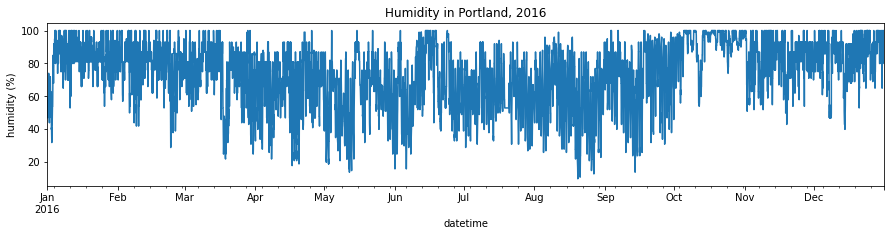

In [8]:
humidity.loc['2016', 'Portland'].plot(figsize=(15, 3))
plt.title('Humidity in Portland, 2016')
plt.ylabel('humidity (%)')
plt.show()

Тот же ряд, но уже с датами на оси. Один год проще читать, чем весь период.

In [9]:
humidity_portland = humidity['Portland'].copy()

humidity_portland = humidity['Portland'].copy() — дальше не трогаем всю таблицу, только один ряд. .copy(), чтобы не задеть исходный humidity.

In [10]:
humidity_portland = humidity_portland.iloc[1:]
humidity_portland = humidity_portland.ffill()
print('пропусков:', humidity_portland.isna().sum())

пропусков: 0


iloc[1:] выкидывает пустой старт в 12:00. ffill() заполняет дырки последним известным значением. Печать: пропусков: 0. Ряд готов к агрегации.

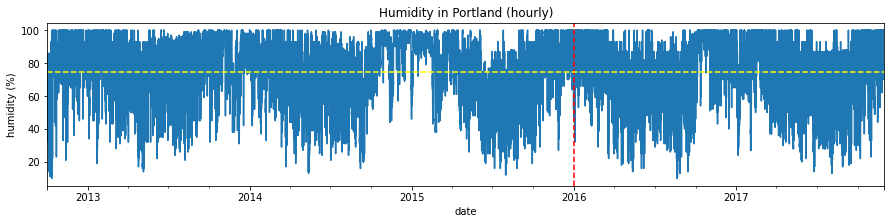

In [11]:
ax = humidity_portland.plot(figsize=(15, 3))
ax.set_title('Humidity in Portland (hourly)')
ax.set_xlabel('date')
ax.set_ylabel('humidity (%)')
ax.axvline('2016-01-01', color='red', linestyle='--')
ax.axhline(humidity_portland.mean(), color='yellow', linestyle='--')
plt.show()

Красный пунктир — 1 января 2016, жёлтый — среднее. Ещё часовая частота, поэтому линия «пила».

In [12]:
humidity_portland.asfreq('D', method='bfill').head()

datetime
2012-10-01 13:00:00    81.0
2012-10-02 13:00:00    71.0
2012-10-03 13:00:00    81.0
2012-10-04 13:00:00    77.0
2012-10-05 13:00:00    57.0
Freq: D, Name: Portland, dtype: float64

Пересадка на дневные метки без усреднения: берётся значение раз в сутки (у тебя с 13:00, потому что после iloc[1:] ряд начинается в 13:00) и дырки заполняются bfill. Это демонстрация смены сетки. Рабочим рядом это не становится.

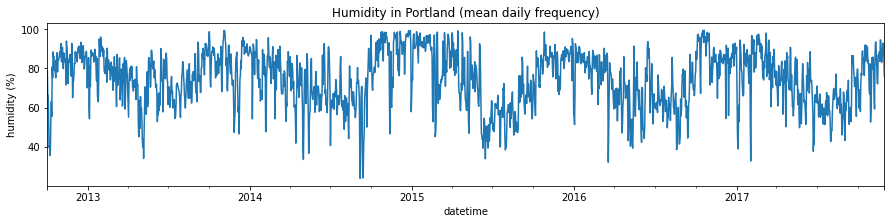

In [13]:
humidity_portland = humidity_portland.resample('D').mean()
humidity_portland.plot(figsize=(15, 3))
plt.title('Humidity in Portland (mean daily frequency)')
plt.ylabel('humidity (%)')
plt.show()

resample('D').mean() — каждый день = среднее по часам. Дальше везде дневной Portland. График спокойнее часового. После этой ячейки объект уже не часовой.

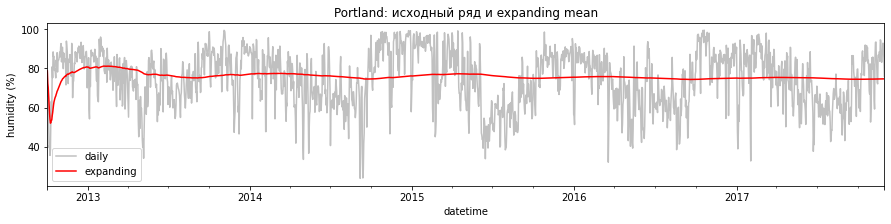

In [14]:
humidity_portland_expanding = humidity_portland.expanding().mean()

humidity_portland.plot(color='silver', figsize=(15, 3))
humidity_portland_expanding.plot(color='red')
plt.title('Portland: исходный ряд и expanding mean')
plt.ylabel('humidity (%)')
plt.legend(['daily', 'expanding'])
plt.show()

Красная линия — среднее с начала ряда до текущей точки. Серая — сам день. Виден медленный уровень, без погоды за три дня.

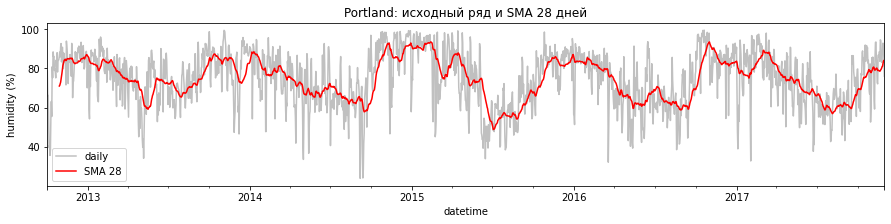

In [15]:
humidity_portland_sliding = humidity_portland.rolling(window=28).mean()

humidity_portland.plot(color='silver', figsize=(15, 3))
humidity_portland_sliding.plot(color='red')
plt.title('Portland: исходный ряд и SMA 28 дней')
plt.ylabel('humidity (%)')
plt.legend(['daily', 'SMA 28'])
plt.show()

Скользящее среднее за месяц. Шум тише, сезонный ход ещё читается. Результат кладётся в humidity_portland_sliding — он пойдёт на годовой график.

полные годы: [2013, 2014, 2015, 2016]


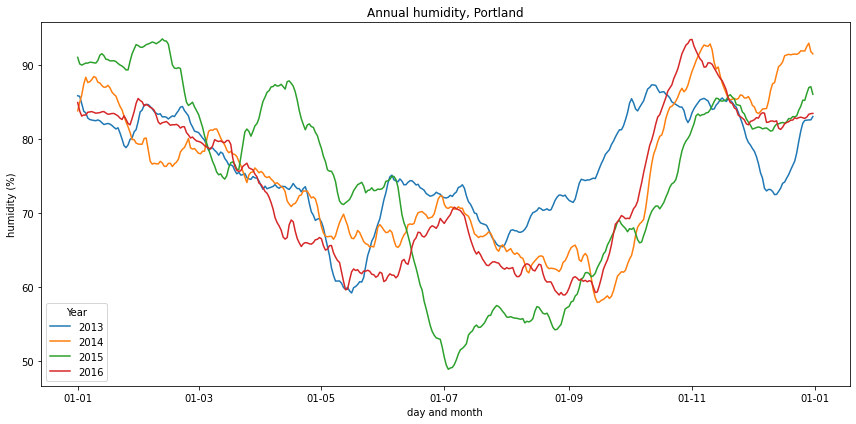

In [16]:
complete_years = [
    year for year, values in humidity_portland.groupby(humidity_portland.index.year)
    if len(values) == pd.Timestamp(year=year, month=12, day=31).dayofyear
]
print('полные годы:', complete_years)

plt.figure(figsize=(12, 6))
for year in complete_years:
    yearly_data = humidity_portland_sliding[humidity_portland_sliding.index.year == year]
    plot_date = pd.to_datetime(yearly_data.index.strftime('2000-%m-%d'))
    plt.plot(plot_date, yearly_data, label=str(year))

plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%m'))
plt.xlabel('day and month')
plt.ylabel('humidity (%)')
plt.title('Annual humidity, Portland')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

В список попадают только годы с 365/366 днями: 2013–2016. Каждый год рисуется на оси «2000-мм-дд», чтобы январь всегда слева. Если горбы совпадают по календарю — сезон. 2012 и 2017 отсекаются как неполные.

In [17]:
monthly = humidity_portland.resample('MS').mean().to_frame(name='Portland')
monthly['MoM'] = monthly['Portland'].pct_change() * 100
monthly['YoY'] = monthly['Portland'].pct_change(12) * 100
monthly.head(15)

,Portland,MoM,YoY
datetime,,,
2012-10-01,72.710288,NaN,NaN
2012-11-01,83.230556,14.468746,NaN
2012-12-01,86.134409,3.488927,NaN
2013-01-01,81.397849,-5.499033,NaN
2013-02-01,81.056548,-0.419301,NaN
2013-03-01,74.981183,-7.495218,NaN
2013-04-01,68.469444,-8.684497,NaN
2013-05-01,68.755376,0.417605,NaN
2013-06-01,72.268056,5.108952,NaN


Ряд сжимается в месяцы (MS). pct_change() — к прошлому месяцу (MoM). pct_change(12) — к тому же месяцу год назад (YoY). Первые YoY пустые, пока нет 12 прошлых месяцев; у тебя YoY начинается с октября 2013.

In [18]:
yearly = humidity_portland.resample('YS').mean().to_frame(name='Portland')
yearly['YoY'] = yearly['Portland'].pct_change() * 100
print(yearly)

monthly['year'] = monthly.index.year
monthly['month'] = monthly.index.month
pivot = monthly.pivot_table(index='year', columns='month', values='MoM')
pivot

             Portland       YoY
datetime                       
2012-01-01  80.664155       NaN
2013-01-01  76.208904 -5.523210
2014-01-01  74.932306 -1.675130
2015-01-01  74.178767 -1.005626
2016-01-01  73.521289 -0.886343
2017-01-01  72.864770 -0.892963


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.468746,3.488927
2013,-5.499033,-0.419301,-7.495218,-8.684497,0.417605,5.108952,-8.714259,10.470233,13.233864,0.924265,-3.707422,3.682566
2014,-3.452735,-1.960913,-3.616636,-7.170455,-5.481873,8.220382,-10.954755,-0.706203,0.110096,37.185140,-1.833810,5.452876
2015,1.019833,-7.795309,-3.524060,-0.819801,-10.586055,-25.636111,3.890790,0.986160,20.055950,18.316251,2.494411,4.313102
2016,-3.106576,-3.541433,-6.727482,-10.544705,-8.973551,12.119333,-8.539597,-4.375810,17.168993,32.648616,-11.114292,1.687212
2017,-8.717602,13.276701,-5.609731,-9.442047,-5.214081,-5.616564,-9.120547,1.053833,10.169600,15.695736,7.770521,NaN


resample('YS') — среднее за год, затем год к году: 2013 −5.5%, дальше около −1%. Сводная year × month из MoM: по горизонтали год внутри сезона, по вертикали один и тот же месяц в разные годы. 2012 заполнен только с осени, декабрь 2017 пустой — ряд там обрывается.

In [19]:
portland_lags = humidity_portland.to_frame(name='Portland')
portland_lags['lag_1'] = portland_lags['Portland'].shift(1)
portland_lags['lead_1'] = portland_lags['Portland'].shift(-1)
portland_lags.head()

,Portland,lag_1,lead_1
datetime,,,
2012-10-01,78.727273,NaN,65.833333
2012-10-02,65.833333,78.727273,66.208333
2012-10-03,66.208333,65.833333,51.166667
2012-10-04,51.166667,66.208333,39.750000
2012-10-05,39.750000,51.166667,40.750000


Новая таблица portland_lags, основной ряд не перезаписывается. shift(1) — вчера, shift(-1) — завтра. В первой строке лаг NaN (вчера нет), лид 2 октября равен Portland 2 октября в следующей строке. Так проверяют, что сдвиг честный.

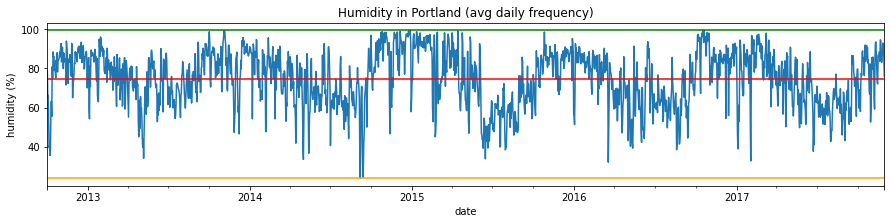

In [20]:
s = humidity_portland

ax = s.plot(figsize=(15, 3), title='Humidity in Portland (avg daily frequency)')
ax.axhline(s.mean(), color='red')
ax.axhline(s.max(), color='green')
ax.axhline(s.min(), color='orange')
ax.set_xlabel('date')
ax.set_ylabel('humidity (%)')
plt.show()

Тот же дневной ряд: красная — среднее, зелёная — максимум, оранжевая — минимум. Коридор влажности одним взглядом. Заголовок уже daily, это верно.

In [21]:
y = humidity_portland.dropna()
variance = np.var(y, ddof=1)
print('дисперсия:', variance)
print('ст. отклонение:', np.sqrt(variance))

дисперсия: 198.4722135223698
ст. отклонение: 14.088016663901623


y — дневной ряд без дырок. Выборочная дисперсия ≈ 198.5, корень ≈ 14.1. Типичный разброс около ±14 пунктов вокруг среднего.

In [22]:
def auto_covariance(series, lag=0):
    x = np.asarray(series, dtype=float)
    x = x[~np.isnan(x)]
    xc = x - x.mean()
    return np.sum(xc[lag:] * xc[:len(x) - lag]) / len(x)

def auto_correlation(series, lag=1):
    return auto_covariance(series, lag) / auto_covariance(series, 0)

print('лаг 0:', auto_covariance(y, 0))
print('лаг 1:', auto_covariance(y, 1))
print('лаг 2:', auto_covariance(y, 2))

for lag in [1, 2, 7, 30, 365]:
    print(f'rho({lag:3d}) = {auto_correlation(y, lag):.3f}')

лаг 0: 198.36703481886033
лаг 1: 157.91390506665772
лаг 2: 123.58669523576057
rho(  1) = 0.796
rho(  2) = 0.623
rho(  7) = 0.451
rho( 30) = 0.330
rho(365) = 0.299


Лаг 0 ≈ дисперсия (деление на N). Лаг 1 и 2 меньше, но далеко не ноль. Нормировка: ρ₁ = 0.796, ρ₂ = 0.623, ρ₇ = 0.451, ρ₃₀ = 0.330, ρ₃₆₅ = 0.299. Память сильная на соседнем дне и умеренная на годе.

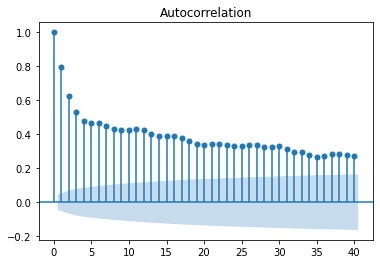

In [23]:
plot_acf(y, lags=40)
plt.show()

Столбики корреляции до лага 40. То же, что цифры выше, только глазом: высокий первый столбик и медленное затухание, не обрыв сразу после нуля.

In [24]:
def adf_test(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, regression='c', autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'],
    )
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)

def kpss_test(timeseries):
    print('Results of KPSS Test:')
    kpsstest = kpss(timeseries, regression='c', nlags='auto')
    kpss_output = pd.Series(
        kpsstest[0:3],
        index=['Test Statistic', 'p-value', 'Lags Used'],
    )
    for key, value in kpsstest[3].items():
        kpss_output[f'Critical Value ({key})'] = value
    print(kpss_output)

Код как в лекции: regression='c' — стационарность вокруг константы. Сами тесты ещё не считаются, только заготовки.

In [25]:
adf_test(y)
print('---')
kpss_test(y)

Results of Dickey-Fuller Test:
Test Statistic                   -4.973203
p-value                           0.000025
#Lags Used                       14.000000
Number of Observations Used    1872.000000
Critical Value (1%)              -3.433848
Critical Value (5%)              -2.863085
Critical Value (10%)             -2.567593
dtype: float64
---
Results of KPSS Test:
Test Statistic            0.21421
p-value                   0.10000
Lags Used                24.00000
Critical Value (10%)      0.34700
Critical Value (5%)       0.46300
Critical Value (2.5%)     0.57400
Critical Value (1%)       0.73900
dtype: float64


C:\Users\n.osipov\Anaconda3_new\lib\site-packages\statsmodels\tsa\stattools.py:1910: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


ADF: stat ≈ −4.97, p ≈ 0.000025 — H0 «есть единичный корень» отвергается, в этом смысле ряд стационарный.

KPSS: stat ≈ 0.21, p = 0.10 и warning «настоящее p больше» — H0 «ряд стационарный» не отвергается.

Оба согласны: уровня-блуждания нет.

In [26]:
lb = acorr_ljungbox(y, return_df=True, lags=[7, 14, 30])
print(lb)

         lb_stat  lb_pvalue
7    4100.942527        0.0
14   6423.355433        0.0
30  10098.338903        0.0


Лаги 7, 14, 30. Все lb_pvalue = 0 — гипотеза «автокорреляций нет» отвергнута. Ряд не белый шум, лаги имеют смысл.

Вывод:
    
Дневная влажность Portland очищена, частота — день. На полных годах 2013–2016 виден сезонный рисунок. MoM показывает короткие месячные сдвиги, YoY на месяцах появляется с октября 2013 и сравнивает одинаковые месяцы; по годам средняя влажность слабо снижается. Лаг 1 совпадает со вчерашним значением, ρ₁ ≈ 0.80. ADF (p ≈ 0.00003) и KPSS (p ≥ 0.10) согласны: единичного корня нет, уровень скорее стационарный. Ljung-Box даёт p = 0 — ряд не белый шум. Первую разность из-за блуждания брать не обязательно, лаги для модели нужны, сезон на графике остаётся.